<a href="https://colab.research.google.com/github/abineshabi1027/SKILLINFYTECH/blob/main/skillinfyproj2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Correlation Matrix ---
            Recency  Frequency  Monetary
Recency    1.000000  -0.403359 -0.388156
Frequency -0.403359   1.000000  0.896549
Monetary  -0.388156   0.896549  1.000000


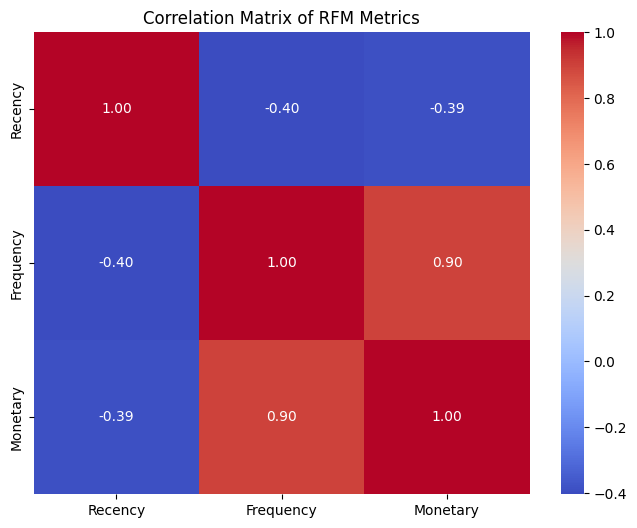


--- Top Customer Segments ---
            Recency  Frequency     Monetary R_Score F_Score M_Score  \
CustomerID                                                            
1               143          9  1767.476010       1       4       4   
2                 8         10  2015.178290       4       4       4   
3                25          7  2207.777772       3       3       4   
4                52          5   707.986946       3       2       2   
5               196          3   578.219623       1       1       1   

           RFM_Segment  
CustomerID              
1                  144  
2                  444  
3                  334  
4                  322  
5                  111  


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta

np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
data = {
    'CustomerID': np.random.randint(1, 101, 500),
    'OrderDate': np.random.choice(dates, 500),
    'OrderValue': np.random.uniform(10, 500, 500)
}
df = pd.DataFrame(data)

analysis_date = df['OrderDate'].max() + timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (analysis_date - x.max()).days,
    'CustomerID': 'count',
    'OrderValue': 'sum'
}).rename(columns={'OrderDate': 'Recency', 'CustomerID': 'Frequency', 'OrderValue': 'Monetary'})

print("--- Correlation Matrix ---")
print(rfm.corr())

plt.figure(figsize=(8, 6))
sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of RFM Metrics')
plt.show()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
print("\n--- Top Customer Segments ---")
print(rfm.head())